# PharmaSystem — Analise Exploratoria com Pandas

**Modulo 03 do portfolio — Semana 3 de 12**

Este notebook faz a analise exploratoria dos dados de vendas da rede ficticia PharmaMinas.

**Autor:** Lucas Verissimo (UNIMONTES — Engenharia de Sistemas)
**Ferramentas:** Python 3.10+, Pandas, NumPy, Matplotlib, Seaborn, openpyxl

---


## Sumario

1. [Setup](#1.-Setup)
2. [Carregamento dos dados](#2.-Carregamento-dos-dados)
3. [Diagnostico e limpeza](#3.-Diagnostico-e-limpeza)
4. [Colunas derivadas](#4.-Colunas-derivadas)
5. [DataFrame master (denormalizado)](#5.-DataFrame-master-denormalizado)
6. [KPIs gerais](#6.-KPIs-gerais)
7. [Analise temporal](#7.-Analise-temporal)
8. [Ranking de filiais](#8.-Ranking-de-filiais)
9. [Analise de produtos](#9.-Analise-de-produtos)
10. [Analise de categorias](#10.-Analise-de-categorias)
11. [Analise de formas de pagamento](#11.-Analise-de-formas-de-pagamento)
12. [Distribuicao por dia da semana](#12.-Distribuicao-por-dia-da-semana)
13. [Analise de clientes (RFM basico)](#13.-Analise-de-clientes)
14. [Segmentacao por faixa etaria](#14.-Segmentacao-por-faixa-etaria)
15. [Correlacoes](#15.-Correlacoes)
16. [Curva de Pareto](#16.-Curva-de-Pareto)
17. [Insights de negocio](#17.-Insights-de-negocio)
18. [Exportacao para Excel](#18.-Exportacao-para-Excel)


## 1. Setup


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Adicionar raiz ao path para importar o pacote src
sys.path.insert(0, '..')

from src.carregamento import carregar_todas_tabelas, resumir_tabelas
from src.limpeza import limpar_e_derivar, criar_dataframe_master, diagnosticar
from src import analises, graficos
from src.exportacao import gerar_relatorio_excel

graficos.aplicar_estilo()
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

print('Setup concluido.')


Setup concluido.



## 2. Carregamento dos dados

As 8 tabelas do PharmaSystem sao carregadas dos CSVs. Os tipos ja vem corretos pelo modulo `carregamento.py`.


In [ ]:
dados = carregar_todas_tabelas('../dados')
print(f'Tabelas carregadas: {list(dados.keys())}')
resumir_tabelas(dados)[['tabela', 'linhas', 'colunas']]


Tabelas carregadas: ['filiais', 'categorias', 'produtos', 'estoque', 'clientes', 'vendas', 'itens_venda', 'calendario']



,tabela,linhas,colunas
0,filiais,15,9
1,categorias,10,3
2,produtos,71,10
3,estoque,1065,4
4,clientes,200,9
5,vendas,1500,8
6,itens_venda,3253,6
7,calendario,912,10


## 3. Diagnostico e limpeza

Antes de qualquer analise, verificamos: nulos, tipos, unicos. O diagnostico abaixo e da tabela `vendas`.


In [ ]:
diagnosticar(dados['vendas'], 'vendas')


,coluna,tipo,nulos,pct_nulos,unicos
0,id,Int64,0,0.00,1500
1,filial_id,Int64,0,0.00,15
2,cliente_id,Int64,323,21.53,200
3,data_venda,datetime64[us],0,0.00,1499
4,valor_total,float64,0,0.00,919
5,desconto,float64,0,0.00,143
6,forma_pagamento,string,0,0.00,5
7,status,string,0,0.00,2


**Observacoes:**
- Coluna `cliente_id` tem nulos — vendas sem cliente identificado (chapa branca).
- Todos os tipos estao corretos.
- Nao ha duplicatas evidentes (unicos = linhas nas chaves).


## 4. Colunas derivadas

Aplicamos as transformacoes definidas em `limpeza.py`:
- Vendas: valor liquido, ano/mes, dia da semana, hora, flag de fim de semana
- Produtos: margem de lucro absoluta e percentual
- Clientes: idade e faixa etaria


In [ ]:
dados_limpos = limpar_e_derivar(dados)

# Preview vendas com colunas derivadas
cols_novas = ['valor_liquido', 'ano_mes', 'dia_semana_nome', 'eh_final_de_semana']
dados_limpos['vendas'][['id', 'data_venda', 'valor_total', 'desconto'] + cols_novas].head()


,id,data_venda,valor_total,desconto,valor_liquido,ano_mes,dia_semana_nome,eh_final_de_semana
0,1,2026-06-14 09:11:00,95.8,0.00,95.80,2026-06,Domingo,True
1,2,2025-12-12 17:03:00,153.3,18.51,134.79,2025-12,Sexta,False
2,3,2026-04-04 16:25:00,21.5,0.00,21.50,2026-04,Sabado,True
3,4,2026-04-23 20:41:00,650.1,0.00,650.10,2026-04,Quinta,False
4,5,2026-03-21 21:49:00,224.2,13.36,210.84,2026-03,Sabado,True


In [ ]:
# Produtos com margem
dados_limpos['produtos'][['nome', 'preco_custo', 'preco_venda', 'margem_lucro', 'margem_percentual']].head()


,nome,preco_custo,preco_venda,margem_lucro,margem_percentual
0,Dipirona Sodica 500mg 20 comprimidos,4.2,8.9,4.7,52.81
1,Paracetamol 750mg 20 comprimidos,5.1,10.5,5.4,51.43
2,Ibuprofeno 400mg 20 comprimidos,6.3,13.2,6.9,52.27
3,Omeprazol 20mg 28 capsulas,7.8,16.9,9.1,53.85
4,Amoxicilina 500mg 21 capsulas,18.5,39.9,21.4,53.63


## 5. DataFrame master (denormalizado)

Criamos um `master` que junta `itens_venda` + `vendas` + `produtos` + `categorias` + `filiais` + `clientes`. Cada linha e um item vendido com TODO o contexto — otimo para agregacoes complexas.


In [ ]:
master = criar_dataframe_master(dados_limpos)
print(f'Shape do master: {master.shape}')
print(f'Colunas ({len(master.columns)}):')
for c in master.columns:
    print(f'  - {c}')


Shape do master: (3253, 34)
Colunas (34):
  - item_id
  - venda_id
  - produto_id
  - quantidade
  - preco_unitario
  - subtotal
  - filial_id
  - cliente_id
  - data_venda
  - forma_pagamento
  - status
  - ano_mes
  - dia_semana_nome
  - eh_final_de_semana
  - ano
  - mes
  - produto_nome
  - categoria_id
  - produto_fabricante
  - preco_custo
  - preco_venda
  - margem_lucro
  - margem_percentual
  - exige_receita
  - categoria_nome
  - filial_nome
  - filial_cidade
  - filial_estado
  - cliente_nome
  - cliente_cidade
  - cliente_estado
  - cliente_idade
  - faixa_etaria
  - margem_item



## 6. KPIs gerais

Metricas de alto nivel do periodo analisado (todas as vendas concluidas).


In [ ]:
kpis = analises.kpis_gerais(master)
for k, v in kpis.items():
    if isinstance(v, float):
        print(f'  {k}: {v:,.2f}')
    else:
        print(f'  {k}: {v}')


  faturamento_total: 226,548.60
  total_vendas: 1458
  total_itens_vendidos: 4247
  ticket_medio: 155.38
  margem_bruta_total: 123,224.20
  percentual_margem: 54.39
  clientes_ativos: 200
  produtos_vendidos_distintos: 71
  filiais_ativas: 15



## 7. Analise temporal

Evolucao do faturamento agregado por mes.


In [ ]:
fat_mensal = analises.faturamento_mensal(master)
fat_mensal.tail(10)


,ano_mes,faturamento,n_vendas,ticket_medio
20,2025-09,14667.6,104,141.034615
21,2025-10,17020.8,103,165.250485
22,2025-11,14254.2,94,151.640426
23,2025-12,10293.5,84,122.541667
24,2026-01,15558.7,102,152.536275
25,2026-02,12034.9,80,150.436250
26,2026-03,15211.5,85,178.958824
27,2026-04,14754.1,92,160.370652
28,2026-05,13391.8,92,145.563043
29,2026-06,18084.5,98,184.535714


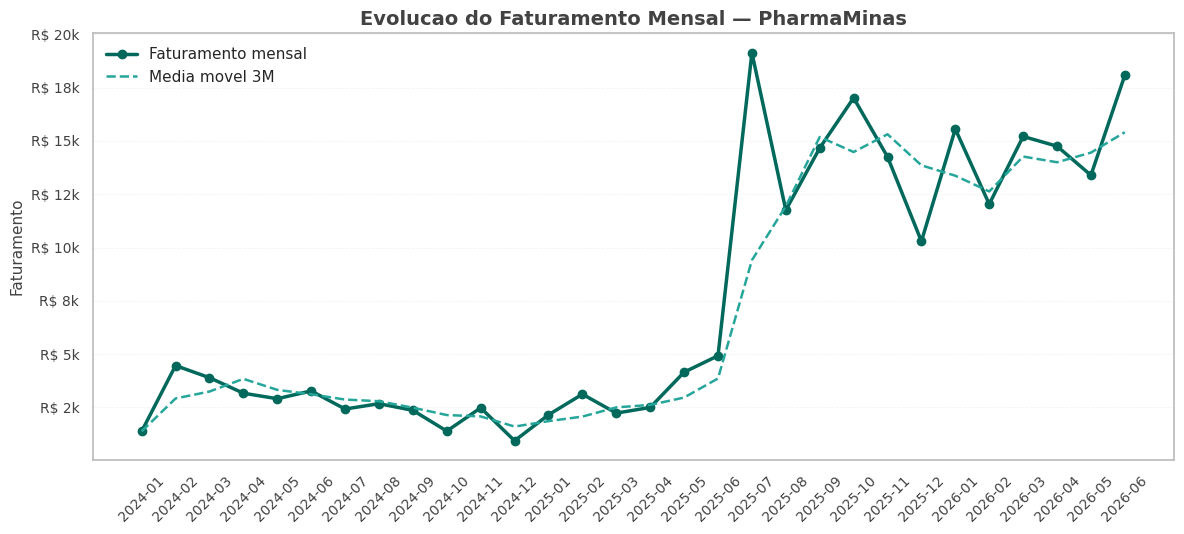

In [ ]:
fig = graficos.grafico_faturamento_mensal(fat_mensal)
plt.show()


## 8. Ranking de filiais

Quais unidades da rede performam melhor? Analisamos por faturamento total, numero de vendas e ticket medio.


In [ ]:
fat_filial = analises.faturamento_por_filial(master)
fat_filial.head(10)


,filial_nome,filial_cidade,faturamento,n_vendas,ticket_medio,percentual_do_total,ranking
0,PharmaMinas Belo Horizonte Savassi,Belo Horizonte,42822.9,234,183.003846,18.90,1
3,PharmaMinas Centro Montes Claros,Montes Claros,27830.5,184,151.252717,12.28,2
14,PharmaMinas Uberlandia Centro,Uberlandia,27559.2,184,149.778261,12.16,3
13,PharmaMinas Todos os Santos,Montes Claros,26289.6,166,158.371084,11.60,4
8,PharmaMinas Ibituruna,Montes Claros,14116.6,102,138.398039,6.23,5
10,PharmaMinas Major Prates,Montes Claros,13619.3,106,128.483962,6.01,6
6,PharmaMinas Diamantina,Diamantina,12155.9,58,209.584483,5.37,7
12,PharmaMinas Salinas,Salinas,10953.3,58,188.850000,4.83,8
4,PharmaMinas Corinto,Corinto,10316.8,60,171.946667,4.55,9
2,PharmaMinas Buritizeiro,Buritizeiro,8237.5,57,144.517544,3.64,10


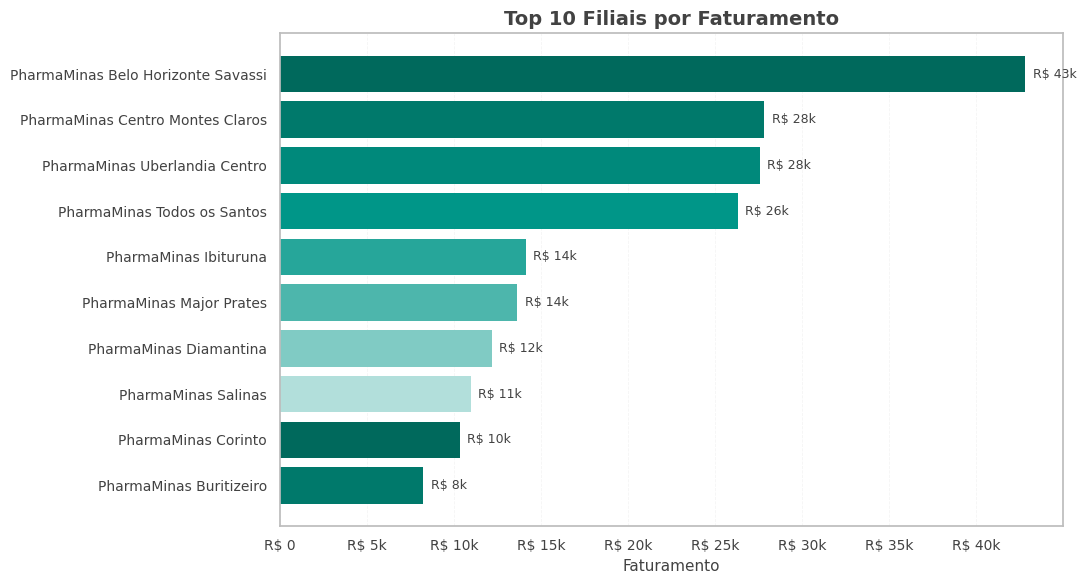

In [ ]:
fig = graficos.grafico_top_filiais(fat_filial, top_n=10)
plt.show()


## 9. Analise de produtos

Top produtos por faturamento e distribuicao de precos.


In [ ]:
ranking = analises.ranking_produtos(master, top_n=15)
ranking[['produto_nome', 'categoria_nome', 'unidades_vendidas', 'faturamento', 'margem_percentual']]


,produto_nome,categoria_nome,unidades_vendidas,faturamento,margem_percentual
0,Aparelho Pressao Digital Omron,Primeiros Socorros,78,32752.2,54.87
1,Perfume Essencial Natura 100ml,Perfumaria,78,16372.2,54.36
2,Serum Vitamina C Adcos 30ml,Dermocosmeticos,71,13482.9,52.87
3,Perfume Malbec Boticario 100ml,Perfumaria,53,10329.7,54.08
4,Creme Antissinais Vichy 50ml,Dermocosmeticos,66,9827.4,54.47
5,Perfume Egeo Boticario 90ml,Perfumaria,56,9660.0,54.26
6,Perfume Kaiak Natura 100ml,Perfumaria,57,8544.3,54.3
7,Whey Protein Growth 1kg,Suplementos Alimentares,49,8325.1,53.56
8,Creatina Integralmedica 300g,Suplementos Alimentares,58,6896.2,54.42
9,Protetor Solar La Roche FPS 60 60ml,Dermocosmeticos,65,6428.5,54.3


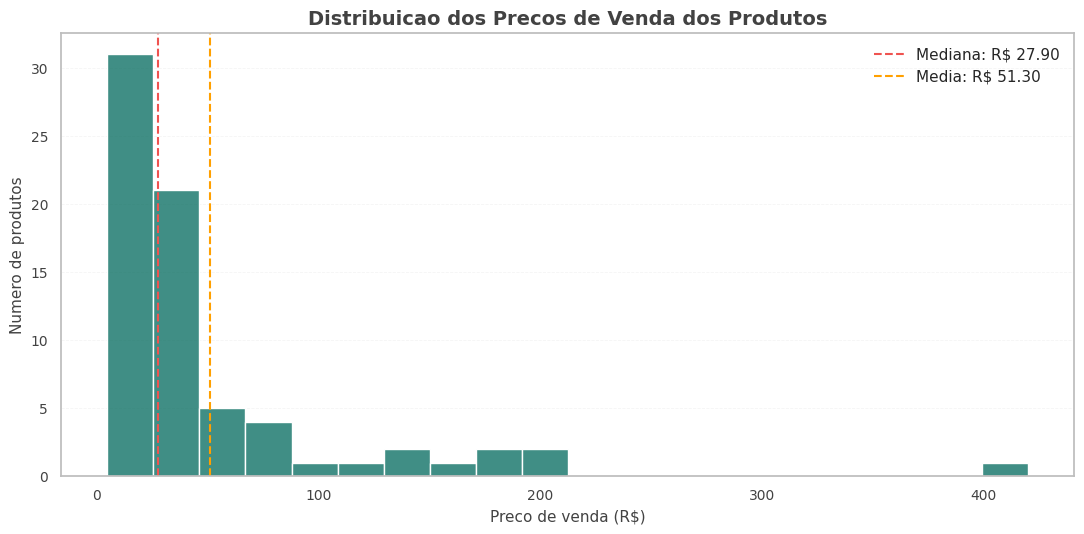

In [ ]:
fig = graficos.grafico_distribuicao_precos(dados_limpos['produtos'])
plt.show()


## 10. Analise de categorias


In [ ]:
fat_categoria = analises.faturamento_por_categoria(master)
fat_categoria


,categoria_nome,faturamento,margem,unidades,n_produtos,margem_percentual,percentual_do_total
7,Perfumaria,44906.2,24367.4,244,4,54.26,19.82
8,Primeiros Socorros,44815.7,24558.4,588,10,54.8,19.78
1,Dermocosmeticos,38202.2,20578.3,312,5,53.87,16.86
9,Suplementos Alimentares,28924.6,15711.7,446,8,54.32,12.77
6,Medicamentos de Referencia,18763.7,10188.3,481,8,54.3,8.28
3,Infantil,15725.2,8617.8,432,7,54.8,6.94
4,Medicamentos Genericos,13114.1,7065.8,629,10,53.88,5.79
2,Higiene Pessoal,11679.6,6320.2,603,10,54.11,5.16
0,Cosmeticos,5513.2,3135.7,264,5,56.88,2.43
5,Medicamentos Similares,4904.1,2680.6,248,4,54.66,2.16


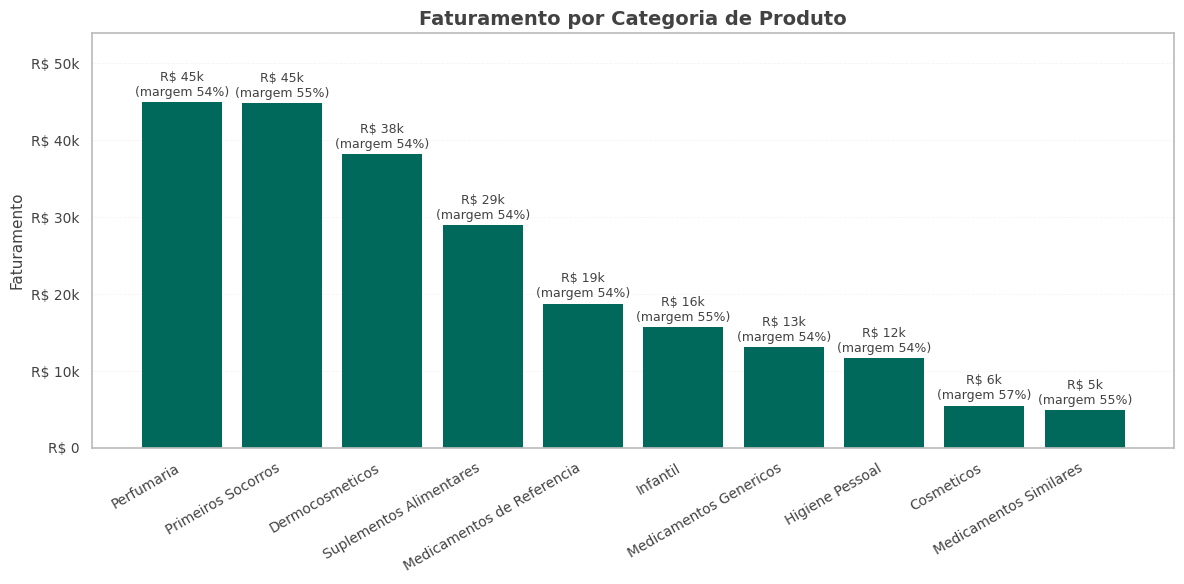

In [ ]:
fig = graficos.grafico_categorias(fat_categoria)
plt.show()


**Boxplot de margem** por categoria mostra dispersao/outliers:


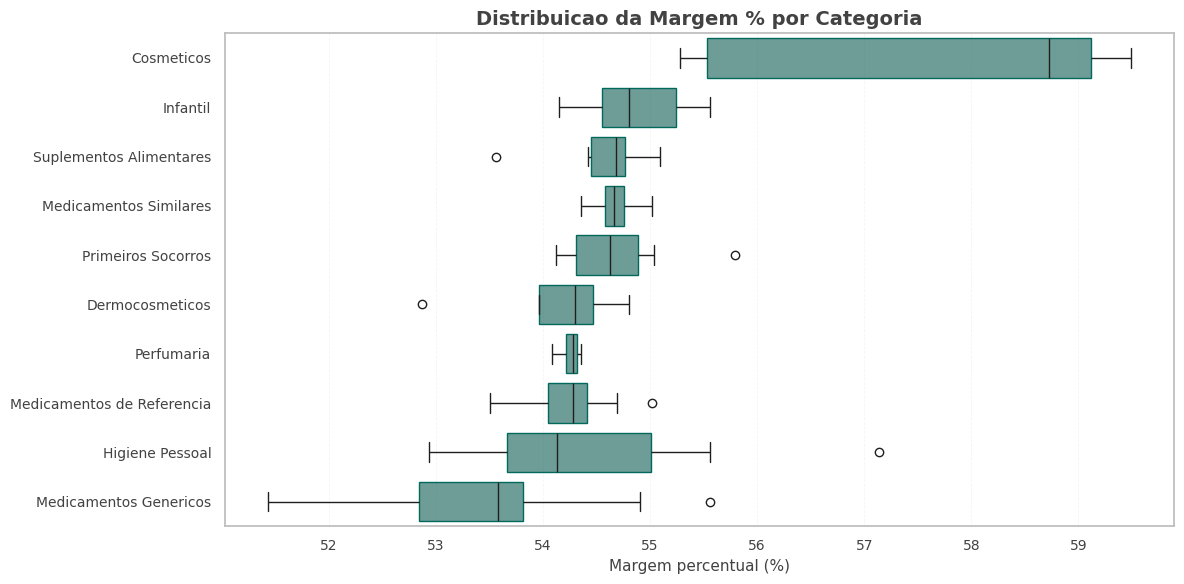

In [ ]:
prod_com_cat = dados_limpos['produtos'].merge(
    dados_limpos['categorias'][['id', 'nome']].rename(columns={'nome': 'categoria_nome'}),
    left_on='categoria_id', right_on='id'
)
fig = graficos.grafico_boxplot_margem(prod_com_cat)
plt.show()


## 11. Analise de formas de pagamento


In [ ]:
fat_pagamento = analises.faturamento_por_pagamento(master)
fat_pagamento


,forma_pagamento,faturamento,n_vendas,percentual_do_total
0,CARTAO_CREDITO,76557.2,514,33.79
4,PIX,60959.7,368,26.91
1,CARTAO_DEBITO,46536.6,290,20.54
3,DINHEIRO,32319.0,217,14.27
2,CONVENIO,10176.1,69,4.49


## 12. Distribuicao por dia da semana


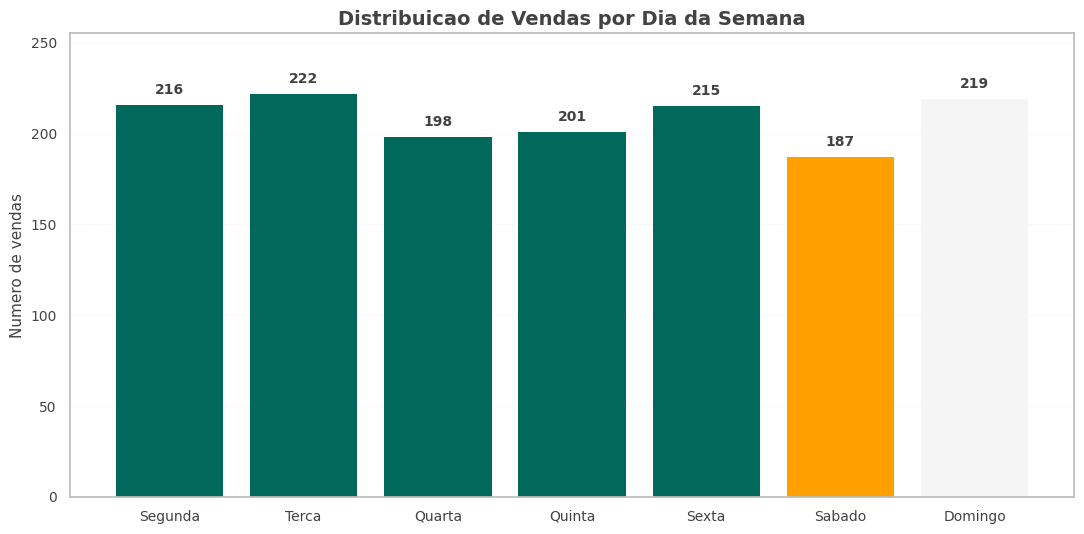

In [ ]:
vendas_dia = analises.vendas_por_dia_semana(master)
fig = graficos.grafico_dia_semana(vendas_dia)
plt.show()


## 13. Analise de clientes (RFM basico)

Analise Recency-Frequency-Monetary:
- **Recency:** `dias_desde_ultima` — quantos dias desde a ultima compra
- **Frequency:** `n_compras` — quantas transacoes por cliente
- **Monetary:** `ltv` — valor total gasto (Lifetime Value)


In [ ]:
clientes = analises.analise_clientes(master)
clientes[['cliente_nome', 'n_compras', 'ltv', 'ticket_medio', 'dias_desde_ultima', 'status', 'quartil_ltv']].head(10)


,cliente_nome,n_compras,ltv,ticket_medio,dias_desde_ultima,status,quartil_ltv
0,Kaique Barbosa Martins,8,2871.4,358.925000,13,Ativo,Q4 (alto)
1,Gabriela Rodrigues Oliveira,6,2658.9,443.150000,25,Ativo,Q4 (alto)
2,Debora Cardoso Dias,7,2390.5,341.500000,5,Ativo,Q4 (alto)
3,Tatiana Rodrigues Ferreira,8,2370.8,296.350000,9,Ativo,Q4 (alto)
4,Heloisa Machado Machado,6,2365.5,394.250000,35,Ativo,Q4 (alto)
5,Patricia Lopes Silva,7,2303.2,329.028571,96,Em risco,Q4 (alto)
6,Sabrina Souza Rodrigues,8,2268.9,283.612500,7,Ativo,Q4 (alto)
7,Carla Gomes Silva,13,2267.7,174.438462,2,Ativo,Q4 (alto)
8,Camila Martins Araujo,11,2152.0,195.636364,174,Em risco,Q4 (alto)
9,Heloisa Freitas Nunes,9,2149.3,238.811111,11,Ativo,Q4 (alto)


**Frequencia de compra:**


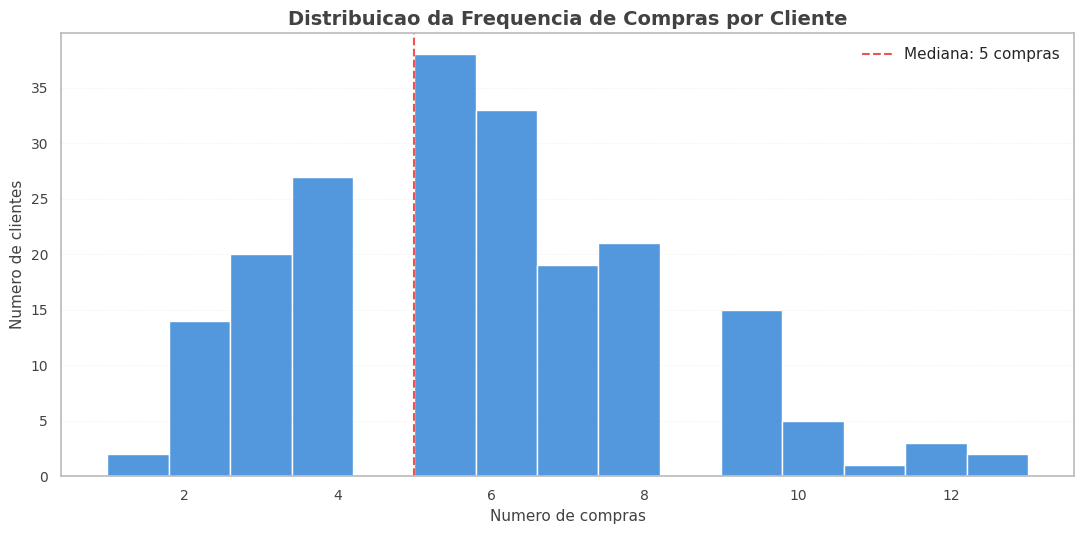

In [ ]:
fig = graficos.grafico_frequencia_compra(clientes)
plt.show()


## 14. Segmentacao por faixa etaria


In [ ]:
seg_etaria = analises.segmentacao_faixa_etaria(master)
seg_etaria


,faixa_etaria,faturamento,n_clientes,n_vendas,ticket_medio,percentual
0,1. Ate 24 anos,23846.5,30,166,143.65,13.45
1,2. 25 a 34,40792.8,44,269,151.65,23.00
2,3. 35 a 44,17359.6,23,122,142.29,9.79
3,4. 45 a 59,46870.0,51,292,160.51,26.43
4,5. 60+ anos,48478.0,52,296,163.78,27.34


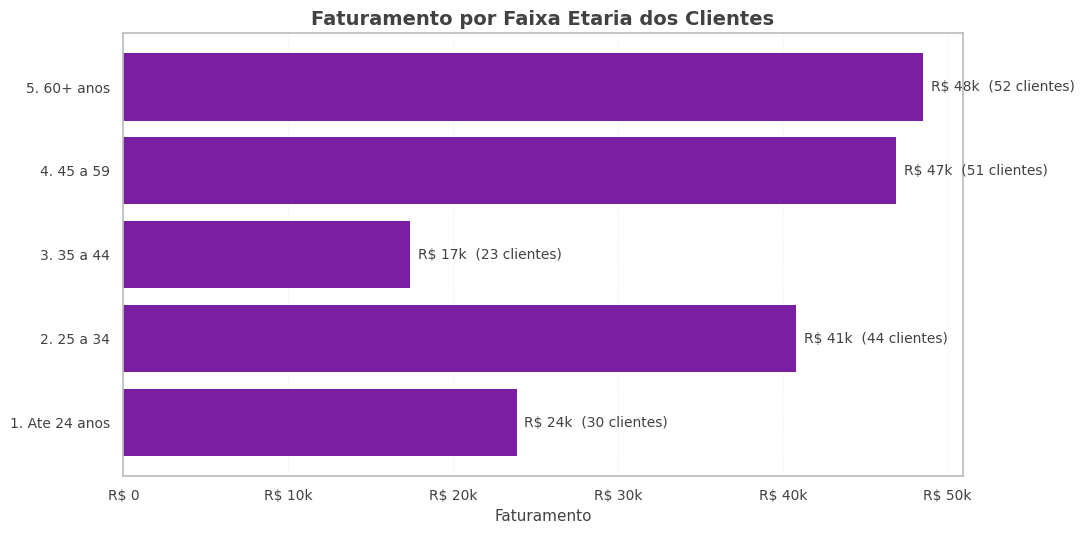

In [ ]:
fig = graficos.grafico_faixa_etaria(seg_etaria)
plt.show()


## 15. Correlacoes

Heatmap de correlacao entre variaveis numericas revela relacoes esperadas (preco x subtotal) e nao-obvias.


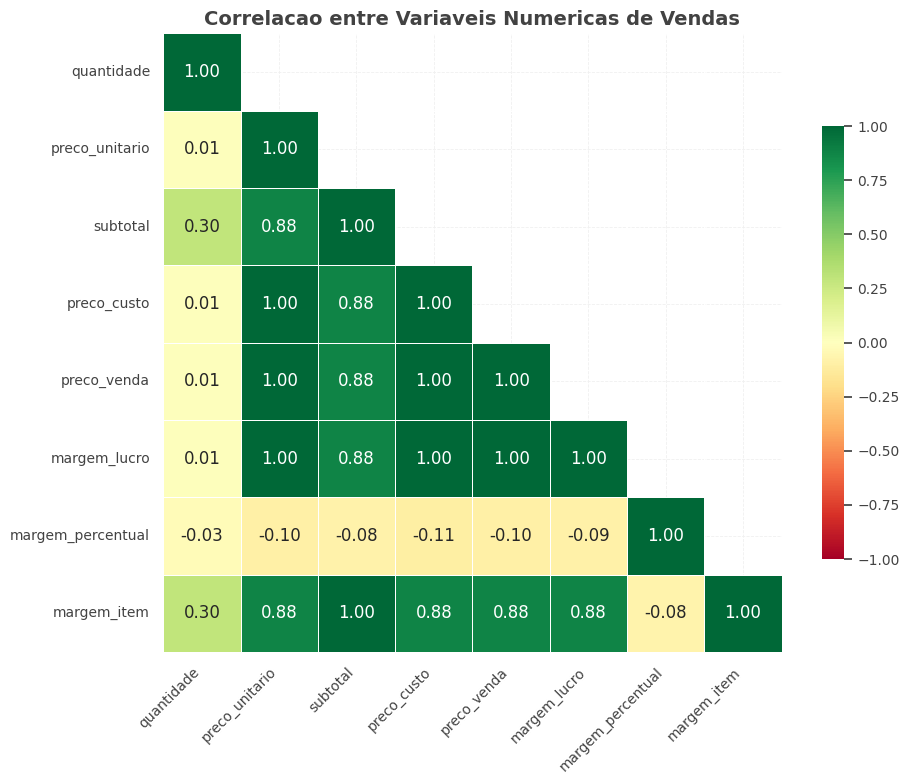

In [ ]:
matriz = analises.matriz_correlacao(master)
fig = graficos.grafico_heatmap_correlacao(matriz)
plt.show()


## 16. Curva de Pareto

A regra 80/20 se aplica ao catalogo? Quantos produtos concentram 80% do faturamento?


In [ ]:
conc = analises.concentracao_top_10(master)
for k, v in conc.items():
    print(f'  {k}: {v}')


Total de produtos com venda: 71
Faturamento total: R$ 226,548.60
Faturamento top 10: R$ 122,618.50
Concentracao top 10: 54.1%
Produtos para 80% do faturamento: 30



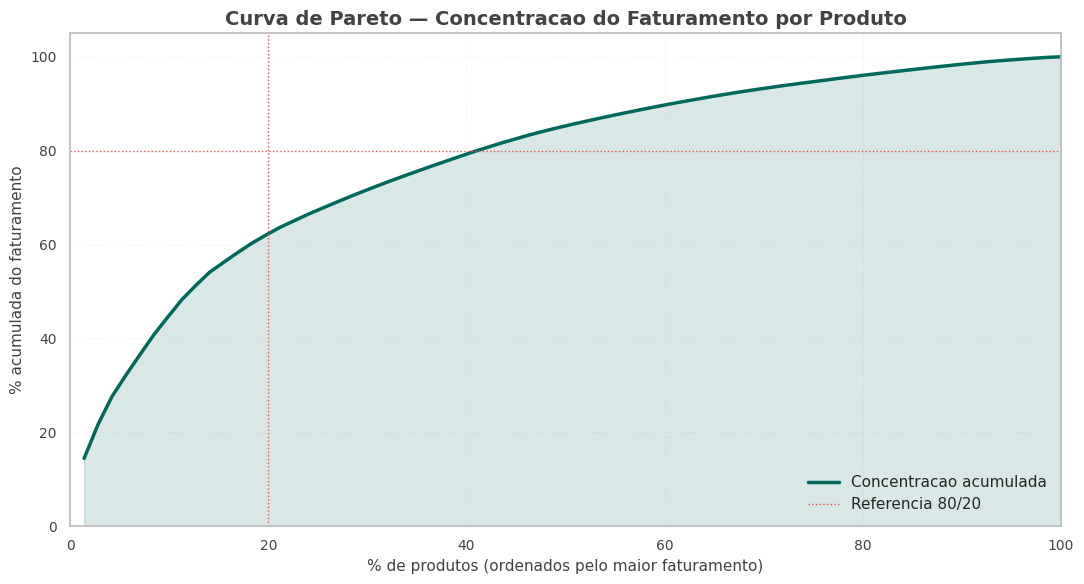

In [ ]:
ranking_full = analises.ranking_produtos(master, top_n=None)
fig = graficos.grafico_pareto_produtos(ranking_full)
plt.show()


## 17. Insights de negocio

Sintese executiva dos achados principais desta analise.


### Insights principais
**1.** O faturamento total do periodo foi de R$ 226,548.60, distribuido em 1,458 vendas concluidas e 4,247 itens comercializados. O ticket medio ficou em R$ 155.38.

**2.** A margem bruta acumulada foi de R$ 123,224.20 (54.4% sobre o faturamento). A categoria de MAIOR margem foi 'Cosmeticos' (56.9%) e a de MENOR foi 'Dermocosmeticos' (53.9%).

**3.** A filial lider foi 'PharmaMinas Belo Horizonte Savassi' em Belo Horizonte, com faturamento de R$ 42,822.90 (18.9% do total) — mais de 3x acima da mediana. Ha oportunidade de estudar suas praticas para replicar em outras unidades.

**4.** Concentracao top 10 produtos: 54.1% do faturamento vem de apenas 10 SKUs. A regra 80/20 exige 30 produtos para atingir 80% do faturamento (de 71 SKUs vendidos). Isso indica um catalogo relativamente diversificado, com riscos moderados de dependencia de poucos produtos.

**5.** O comportamento por dia da semana mostra ticket medio de R$ 153.83 nos fins de semana contra R$ 155.98 nos dias uteis, uma diferenca de -1.4%. Isso sugere que campanhas focadas em fim de semana podem ter maior retorno por transacao.

**6.** A base de clientes conta com 200 compradores identificados. A categoria 'Perfumaria' lidera em faturamento (R$ 44,906.20, 19.8% do total), sugerindo forte aderencia ao mix desta categoria — vale investigar sortimento e posicionamento na loja fisica.



## 18. Exportacao para Excel

Gera relatorio multi-aba consumivel pela diretoria.


In [ ]:
from src.exportacao import gerar_relatorio_excel

ranking_export = analises.ranking_produtos(master, top_n=20)
top_clientes_export = analises.top_clientes(master, top_n=20)
insights = [
    'Faturamento total: R$ 226.548,60 em 1.458 vendas concluidas.',
    'Margem bruta acumulada: 54,4%.',
    'Filial lider: PharmaMinas BH Savassi (18,9% do total).',
    'Concentracao top 10 produtos: 54,1% do faturamento.',
    'Ticket medio em finais de semana: comparavel aos dias uteis.',
    'Categoria mais rentavel: Perfumaria (lidera em faturamento).',
]

arquivo = gerar_relatorio_excel(
    kpis=kpis,
    faturamento_mensal=fat_mensal,
    faturamento_filial=fat_filial,
    ranking_produtos=ranking_export,
    top_clientes=top_clientes_export,
    segmentacao_etaria=seg_etaria,
    faturamento_categoria=fat_categoria,
    faturamento_pagamento=fat_pagamento,
    insights=insights,
    caminho_saida='../exports/relatorio_pharma_system.xlsx',
)
print(f'Excel gerado: {arquivo}')


Excel gerado: ../exports/relatorio_pharma_system.xlsx



---

## Proximos passos

1. Explorar cohort analysis de clientes (Modulo 05+).
2. Modelar previsao de vendas (Modulo 07 — ML basico).
3. Automatizar o pipeline com ETL agendado (Modulo 04).

**Fim do notebook.**
